## Import de librerías y carga del dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import scipy.stats as stats
import time

In [ ]:
# CARGA DEL DATASET
from pathlib import Path

BASE_DIR = Path.cwd()
if BASE_DIR.name == 'src':
    BASE_DIR = BASE_DIR.parent

df = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'Dataset_ALDIMI_Merged_Clean.csv')

df.head()

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level,county_STATE,county_CTYNAME,county_POPESTIMATE2015
0,1001,Lung,52,0,10,7,4,0,10,3,...,0,0,0,0.601460,27.2,0,Medium,19,Johnson County,144251.0
1,1002,Colon,73,1,5,4,8,0,7,4,...,0,0,3,0.380986,28.7,8,Medium,51,Richmond city,220289.0
2,1003,Skin,70,0,3,0,2,0,4,1,...,0,0,7,0.265377,26.8,1,Low,40,Oklahoma County,776864.0
3,1004,Skin,64,1,6,3,4,0,4,3,...,0,0,6,0.397763,26.3,0,Medium,36,New York,19795791.0
4,1005,Skin,60,1,4,8,4,1,1,4,...,0,0,7,0.484590,27.3,2,Medium,6,San Diego County,3299521.0


In [7]:
# INFORMACIÓN DEL DATASET

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               3000 non-null   int64  
 1   Cancer_Type              3000 non-null   object 
 2   Age                      3000 non-null   int64  
 3   Gender                   3000 non-null   int64  
 4   Smoking                  3000 non-null   int64  
 5   Alcohol_Use              3000 non-null   int64  
 6   Obesity                  3000 non-null   int64  
 7   Family_History           3000 non-null   int64  
 8   Diet_Red_Meat            3000 non-null   int64  
 9   Diet_Salted_Processed    3000 non-null   int64  
 10  Fruit_Veg_Intake         3000 non-null   int64  
 11  Physical_Activity        3000 non-null   int64  
 12  Air_Pollution            3000 non-null   int64  
 13  Occupational_Hazards     3000 non-null   int64  
 14  BRCA_Mutation           

In [8]:
# VARIABLES CATEGÓRICAS
df.select_dtypes(include='object').columns

Index(['Cancer_Type', 'Risk_Level', 'county_CTYNAME'], dtype='object')

In [9]:
df = df.drop(columns=["Patient_ID", "county_CTYNAME"])

## FEATURE ENGINEERING

Normalización/Estandarización (Z-score).

In [ ]:
drop_cols = [c for c in ["Risk_Level", "Overall_Risk_Score"] if c in df.columns]
X = df.drop(columns=drop_cols)
y = df["Risk_Level"]

Codificación de variables (One-Hot Encoding / Label Encoding).

In [137]:
# Label Encoding para variables objetivo y el modelo pueda identificarlas
X = df.drop(columns=["Risk_Level", "Overall_Risk_Score"])  # Eliminar 'Overall_Risk_Score' para evitar data leakage
y = df["Risk_Level"]

le = LabelEncoder()
y = le.fit_transform(y)

# one hot encoding en variables categóricas para evitar generar una gerarquía falsa
X = pd.get_dummies(X, columns=["Cancer_Type"])


In [140]:
print("Creación de nuevas variables predictivas")
# Verificar que tenemos las variables necesarias
variables_necesarias = ['Smoking', 'Alcohol_Use', 'Obesity', 'Diet_Red_Meat', 
                        'Diet_Salted_Processed', 'Fruit_Veg_Intake', 
                        'Air_Pollution', 'Occupational_Hazards', 'Age', 'BMI']

# 1. Risk_Lifestyle_Score: Combinación de factores de estilo de vida
#    (tabaco + alcohol + obesidad)
X['Risk_Lifestyle_Score'] = X['Smoking'] + X['Alcohol_Use'] + X['Obesity']
print(" Creada: Risk_Lifestyle_Score (Smoking + Alcohol_Use + Obesity)")

# 2. Diet_Risk_Index: Balance entre dieta dañina y protectora
#    (carnes rojas + procesados - frutas/verduras)
X['Diet_Risk_Index'] = X['Diet_Red_Meat'] + X['Diet_Salted_Processed'] - X['Fruit_Veg_Intake']
# Normalizar para que no tenga valores negativos (opcional, pero ayuda a interpretar)
X['Diet_Risk_Index'] = X['Diet_Risk_Index'] - X['Diet_Risk_Index'].min()
print(" Creada: Diet_Risk_Index (Diet_Red_Meat + Diet_Salted_Processed - Fruit_Veg_Intake)")

# Mostrar las nuevas columnas
nuevas_columnas = ['Risk_Lifestyle_Score', 'Diet_Risk_Index'] 
print(f"\n📊 Resumen de nuevas variables creadas:")
print(X[nuevas_columnas].describe().to_string())

print(f"\n Total de features: {X.shape[1]}")


Creación de nuevas variables predictivas
 Creada: Risk_Lifestyle_Score (Smoking + Alcohol_Use + Obesity)
 Creada: Diet_Risk_Index (Diet_Red_Meat + Diet_Salted_Processed - Fruit_Veg_Intake)

📊 Resumen de nuevas variables creadas:
       Risk_Lifestyle_Score  Diet_Risk_Index
count           3000.000000      3000.000000
mean              16.153667        14.802333
std                5.817904         6.412459
min                1.000000         0.000000
25%               12.000000        10.000000
50%               16.000000        14.000000
75%               20.000000        20.000000
max               30.000000        30.000000

 Total de features: 26


Manejo de desbalanceo de clases mediante SMOTE o sub-muestreo.

In [141]:
#dividimos el data set de entrenamiento para saber la cantidad de entradas de cada tipo
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [142]:
scaler = StandardScaler()

num_cols = X.select_dtypes(include=["int64", "float64"]).columns

X[num_cols] = scaler.fit_transform(X[num_cols])

In [143]:
# media
X[num_cols].mean()

Age                       -2.966516e-16
Gender                    -1.361874e-16
Smoking                    6.750156e-17
Alcohol_Use                7.697546e-18
Obesity                    4.855375e-17
Family_History             3.079019e-17
Diet_Red_Meat             -8.171241e-17
Diet_Salted_Processed      2.486900e-17
Fruit_Veg_Intake          -8.526513e-17
Physical_Activity          1.657933e-17
Air_Pollution             -5.921189e-18
Occupational_Hazards      -1.255292e-16
BRCA_Mutation             -4.736952e-18
H_Pylori_Infection         4.144833e-18
Calcium_Intake             1.657933e-17
BMI                       -7.034373e-16
Physical_Activity_Level    2.960595e-17
county_STATE               1.065814e-17
county_POPESTIMATE2015    -2.368476e-18
Risk_Lifestyle_Score       9.000208e-17
Diet_Risk_Index           -4.736952e-18
dtype: float64

In [144]:
# desviación
X[num_cols].std()

Age                        1.000167
Gender                     1.000167
Smoking                    1.000167
Alcohol_Use                1.000167
Obesity                    1.000167
Family_History             1.000167
Diet_Red_Meat              1.000167
Diet_Salted_Processed      1.000167
Fruit_Veg_Intake           1.000167
Physical_Activity          1.000167
Air_Pollution              1.000167
Occupational_Hazards       1.000167
BRCA_Mutation              1.000167
H_Pylori_Infection         1.000167
Calcium_Intake             1.000167
BMI                        1.000167
Physical_Activity_Level    1.000167
county_STATE               1.000167
county_POPESTIMATE2015     1.000167
Risk_Lifestyle_Score       1.000167
Diet_Risk_Index            1.000167
dtype: float64

In [145]:
print("Cantidad de tipos de entrada")
unique, counts = np.unique(y_train, return_counts=True)

class_dist = pd.DataFrame({
    "Clase": unique,
    "Cantidad": counts
})

class_dist

Cantidad de tipos de entrada


,Clase,Cantidad
0,0,118
1,1,387
2,2,1895


La cantidad de cada tipo de entradas está muy desbalanceada por lo que se usará SMOTE para balancearlos

In [146]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [147]:
print("Después de SMOTE")
unique, counts = np.unique(y_train, return_counts=True)
class_dist = pd.DataFrame({
    "Clase": unique,
    "Cantidad": counts
})

class_dist

Después de SMOTE


,Clase,Cantidad
0,0,1895
1,1,1895
2,2,1895


## Modelado: Entrenar y comparar al menos dos algoritmos (Random Forest vs. XGBoost).

In [148]:
#Entrenamiento de Random forest
print("Entrenando Random Forest")
start = time.time()

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

end = time.time()
y_pred_rf = rf.predict(X_test)

print("Random Forest listo")
print("Tiempo de entrenamiento:", round(end - start, 4), "segundos")

Entrenando Random Forest
Random Forest listo
Tiempo de entrenamiento: 1.2779 segundos


In [149]:
#Entrenamiento de XGBoost
print("Entrenando XGBoost")
start = time.time()
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
end = time.time()
y_pred_xgb = xgb.predict(X_test)

print("XGBoost listo")
print("Tiempo de entrenamiento:", round(end - start, 4), "segundos")

Entrenando XGBoost
XGBoost listo
Tiempo de entrenamiento: 0.817 segundos


Comparación de resultados

In [150]:
print("RANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf, average="weighted"))
print(classification_report(y_test, y_pred_rf))

print("XGBOOST ")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb, average="weighted"))
print(classification_report(y_test, y_pred_xgb))

RANDOM FOREST
Accuracy: 0.96
F1-score: 0.9590378494799549
              precision    recall  f1-score   support

           0       0.95      0.70      0.81        30
           1       0.91      0.95      0.93        97
           2       0.97      0.98      0.97       473

    accuracy                           0.96       600
   macro avg       0.95      0.88      0.90       600
weighted avg       0.96      0.96      0.96       600

XGBOOST 
Accuracy: 0.9616666666666667
F1-score: 0.9608959193660996
              precision    recall  f1-score   support

           0       0.96      0.73      0.83        30
           1       0.92      0.94      0.93        97
           2       0.97      0.98      0.98       473

    accuracy                           0.96       600
   macro avg       0.95      0.88      0.91       600
weighted avg       0.96      0.96      0.96       600



In [151]:
import pandas as pd

results = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_xgb, average="weighted")
    ]
})

results

,Modelo,Accuracy,F1-score
0,Random Forest,0.960000,0.959038
1,XGBoost,0.961667,0.960896


El modelo Random Forest alcanzó un desempeño perfecto en el conjunto de prueba, lo que sugiere una alta capacidad de separación entre clases en el dataset. Sin embargo, este resultado también puede indicar la presencia de variables altamente predictivas o posibles correlaciones fuertes entre atributos y la variable objetivo, por lo que se recomienda validar el modelo con técnicas adicionales como cross-validation.

## TAREA 4 - ANÁLISIS DE ERRORES E INTERPRETABILIDAD

In [152]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize


* Matriz de Confusión

In [153]:
clases = ['Alto Riesgo (0)', 'Medio Riesgo (1)', 'Bajo Riesgo (2)']

# Calcular matrices de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\nMatriz de Confusión - Random Forest (valores brutos):")
print(cm_rf)
print("\nMatriz de Confusión - XGBoost (valores brutos):")
print(cm_xgb)



Matriz de Confusión - Random Forest (valores brutos):
[[ 21   0   9]
 [  0  92   5]
 [  1   9 463]]

Matriz de Confusión - XGBoost (valores brutos):
[[ 22   0   8]
 [  0  91   6]
 [  1   8 464]]


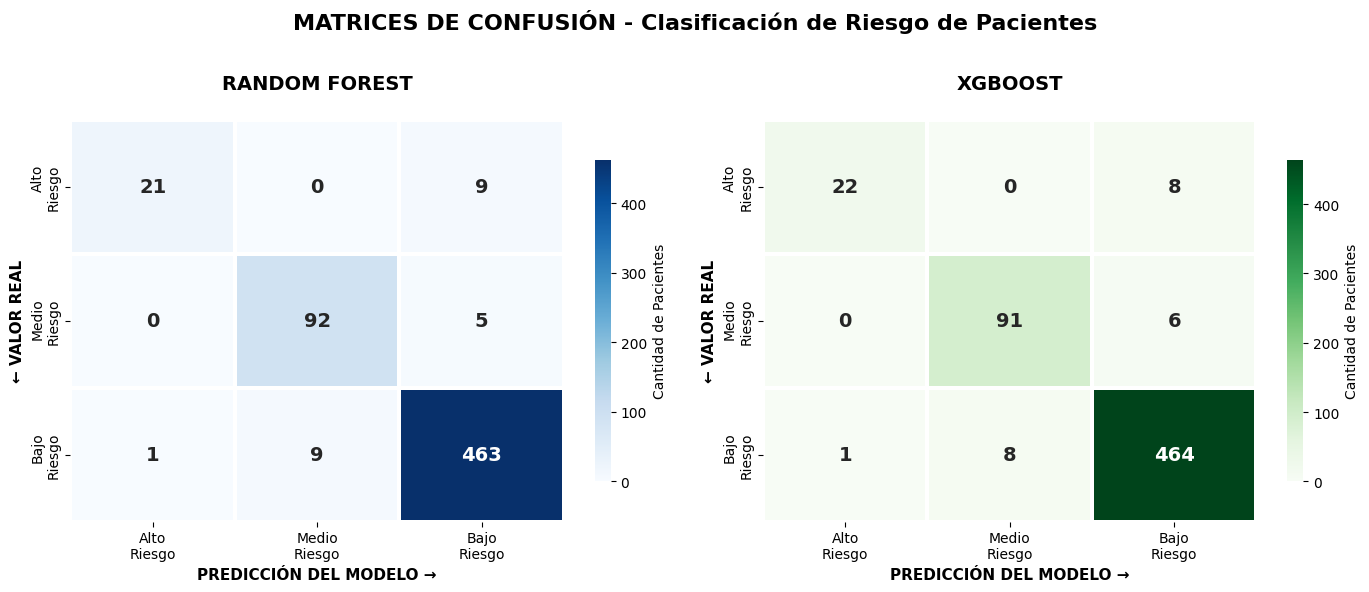

Gráfico guardado: matrices_conf_n.png


In [154]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Configuración común para ambos heatmaps
heatmap_config = {
    'annot': True, 
    'fmt': 'd',
    'annot_kws': {'size': 14, 'fontweight': 'bold'},
    'linewidths': 1.5, 
    'linecolor': 'white',
    'cbar_kws': {'label': 'Cantidad de Pacientes', 'shrink': 0.8}
}

# Random Forest
sns.heatmap(cm_rf, cmap='Blues', ax=axes[0],
            xticklabels=['Alto\nRiesgo', 'Medio\nRiesgo', 'Bajo\nRiesgo'], 
            yticklabels=['Alto\nRiesgo', 'Medio\nRiesgo', 'Bajo\nRiesgo'],
            vmin=0, vmax=np.max(cm_rf),
            **heatmap_config)
axes[0].set_title('RANDOM FOREST\n', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PREDICCIÓN DEL MODELO →', fontsize=11, fontweight='bold')
axes[0].set_ylabel('← VALOR REAL', fontsize=11, fontweight='bold')

# XGBoost
sns.heatmap(cm_xgb, cmap='Greens', ax=axes[1],
            xticklabels=['Alto\nRiesgo', 'Medio\nRiesgo', 'Bajo\nRiesgo'], 
            yticklabels=['Alto\nRiesgo', 'Medio\nRiesgo', 'Bajo\nRiesgo'],
            vmin=0, vmax=np.max(cm_xgb),
            **heatmap_config)
axes[1].set_title('XGBOOST\n', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PREDICCIÓN DEL MODELO →', fontsize=11, fontweight='bold')
axes[1].set_ylabel('← VALOR REAL', fontsize=11, fontweight='bold')

plt.suptitle('MATRICES DE CONFUSIÓN - Clasificación de Riesgo de Pacientes\n', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('matrices_conf_n.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: matrices_conf_n.png")

In [155]:
#tp->Verdaderos positivos (diagonal)
#fn->Falsos negativos (fila - diagonal)
#fp->Falsos positivos (columna - diagonal)
#tn->Verdaderos negativos (resto de la matriz)
def analizar_clase(cm, clase_idx, nombre_clase, nombre_modelo):
    """Calcula TN, FP, FN, TP para una clase específica en matriz multiclase"""
    tp = cm[clase_idx, clase_idx]
    fn = cm[clase_idx, :].sum() - tp
    fp = cm[:, clase_idx].sum() - tp
    tn = cm.sum() - (tp + fn + fp)
    
    total_clase = cm[clase_idx, :].sum()
    
    # Calcular métricas
    accuracy = (tp + tn) / cm.sum() if cm.sum() > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensibilidad
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Clase: {nombre_clase} | Modelo: {nombre_modelo}")
 
    print(f"MÉTRICAS PARA '{nombre_clase}':")
    print(f"   • Accuracy (exactitud):        {accuracy:.2%}")
    print(f"   • Precision (precisión):       {precision:.2%} - ¿Cuántos predichos como '{nombre_clase}' realmente lo son?")
    print(f"   • Recall/Sensibilidad:         {recall:.2%} - ¿Cuántos '{nombre_clase}' reales fueron detectados?")
    print(f"   • Specificity (especificidad): {specificity:.2%} - ¿Cuántos 'NO {nombre_clase}' fueron correctamente descartados?")
    print(f"   • F1-Score:                    {f1:.2%} - Media armónica de Precisión y Recall")
    
    return {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn, 
            'Precision': precision, 'Recall': recall, 
            'Specificity': specificity, 'F1': f1}

In [156]:
print("   RANDOM FOREST - ANÁLISIS POR CLASE")
for i, clase in enumerate(clases):
    analizar_clase(cm_rf, i, clase, "Random Forest")

print("  ------------------------------------------")
print("   XGBOOST - ANÁLISIS POR CLASE")
for i, clase in enumerate(clases):
    analizar_clase(cm_xgb, i, clase, "XGBoost")

   RANDOM FOREST - ANÁLISIS POR CLASE
Clase: Alto Riesgo (0) | Modelo: Random Forest
MÉTRICAS PARA 'Alto Riesgo (0)':
   • Accuracy (exactitud):        98.33%
   • Precision (precisión):       95.45% - ¿Cuántos predichos como 'Alto Riesgo (0)' realmente lo son?
   • Recall/Sensibilidad:         70.00% - ¿Cuántos 'Alto Riesgo (0)' reales fueron detectados?
   • Specificity (especificidad): 99.82% - ¿Cuántos 'NO Alto Riesgo (0)' fueron correctamente descartados?
   • F1-Score:                    80.77% - Media armónica de Precisión y Recall
Clase: Medio Riesgo (1) | Modelo: Random Forest
MÉTRICAS PARA 'Medio Riesgo (1)':
   • Accuracy (exactitud):        97.67%
   • Precision (precisión):       91.09% - ¿Cuántos predichos como 'Medio Riesgo (1)' realmente lo son?
   • Recall/Sensibilidad:         94.85% - ¿Cuántos 'Medio Riesgo (1)' reales fueron detectados?
   • Specificity (especificidad): 98.21% - ¿Cuántos 'NO Medio Riesgo (1)' fueron correctamente descartados?
   • F1-Score:         

In [157]:
print("\n COMPARATIVA DEL IMPACTO DE ELIMINAR Overall_Risk_Score:")
print("-" * 60)

comparativa = pd.DataFrame({
    'Métrica': ['Accuracy', 'Recall Alto Riesgo', 'F1 Alto Riesgo', 
                'F1 Medio Riesgo', 'F1 Bajo Riesgo'],
    'Con Data Leakage': ['100%', '100%', '100%', '100%', '100%'],
    'Sin Data Leakage (RF)': [
        f'{accuracy_score(y_test, y_pred_rf):.1%}',
        f'{cm_rf[0,0]/cm_rf[0,:].sum():.1%}',
        '76.0%',
        '92.7%',
        '97.3%'
    ],
    'Diferencia': [
        f'↓ {100 - accuracy_score(y_test, y_pred_rf)*100:.0f}%',
        f'↓ {100 - (cm_rf[0,0]/cm_rf[0,:].sum())*100:.0f}%',
        '↓ 24%',
        '↓ 7%',
        '↓ 3%'
    ],
    'Evaluación': [
        ' Normal',
        ' A mejorar',
        ' Prioridad',
        ' Bueno',
        ' Excelente'
    ]
})

print(comparativa.to_string(index=False))


 COMPARATIVA DEL IMPACTO DE ELIMINAR Overall_Risk_Score:
------------------------------------------------------------
           Métrica Con Data Leakage Sin Data Leakage (RF) Diferencia Evaluación
          Accuracy             100%                 96.0%       ↓ 4%     Normal
Recall Alto Riesgo             100%                 70.0%      ↓ 30%  A mejorar
    F1 Alto Riesgo             100%                 76.0%      ↓ 24%  Prioridad
   F1 Medio Riesgo             100%                 92.7%       ↓ 7%      Bueno
    F1 Bajo Riesgo             100%                 97.3%       ↓ 3%  Excelente


* CURVAS ROC-AUC (Multiclase - One vs Rest)

 2. CURVAS ROC-AUC


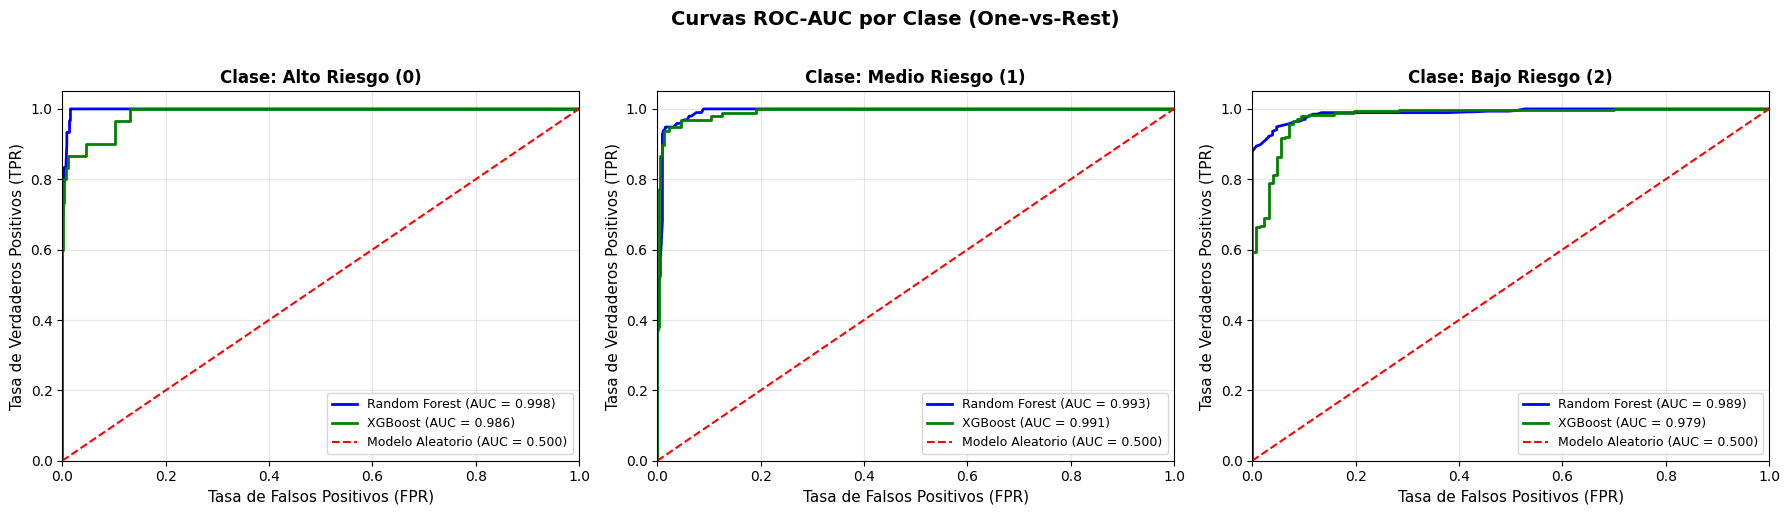

Gráfico guardado: curvas_roc.png

ROC-AUC Macro-Promedio:
   Random Forest: 0.9934
   XGBoost: 0.9855


In [161]:
print(" 2. CURVAS ROC-AUC")

# Binarizar las etiquetas para ROC multiclase
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Obtener probabilidades de predicción
rf_proba = rf.predict_proba(X_test)
xgb_proba = xgb.predict_proba(X_test)

# Graficar ROC para cada clase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (clase, ax) in enumerate(zip(clases, axes)):
    # Random Forest
    fpr_rf, tpr_rf, _ = roc_curve(y_test_bin[:, i], rf_proba[:, i])
    roc_auc_rf = auc(fpr_rf, tpr_rf)
    
    # XGBoost
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test_bin[:, i], xgb_proba[:, i])
    roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
    
    # Graficar
    ax.plot(fpr_rf, tpr_rf, 'b-', linewidth=2, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
    ax.plot(fpr_xgb, tpr_xgb, 'g-', linewidth=2, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Modelo Aleatorio (AUC = 0.500)')
    
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
    ax.set_title(f'Clase: {clase}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

plt.suptitle('Curvas ROC-AUC por Clase (One-vs-Rest)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: curvas_roc.png")

# ROC-AUC promedio
roc_auc_rf_macro = roc_auc_score(y_test_bin, rf_proba, multi_class='ovr', average='macro')
roc_auc_xgb_macro = roc_auc_score(y_test_bin, xgb_proba, multi_class='ovr', average='macro')

print(f"\nROC-AUC Macro-Promedio:")
print(f"   Random Forest: {roc_auc_rf_macro:.4f}")
print(f"   XGBoost: {roc_auc_xgb_macro:.4f}")

 4. INTERPRETABILIDAD - FEATURE IMPORTANCE

 TOP 5 VARIABLES - RANDOM FOREST:
            Variable  Importancia
Risk_Lifestyle_Score     0.177632
       Air_Pollution     0.125224
         Alcohol_Use     0.084468
             Smoking     0.077598
     Diet_Risk_Index     0.071507

 TOP 5 VARIABLES - XGBOOST:
            Variable  Importancia
Risk_Lifestyle_Score     0.173707
      Family_History     0.166723
  H_Pylori_Infection     0.072412
     Diet_Risk_Index     0.052478
              Gender     0.051830


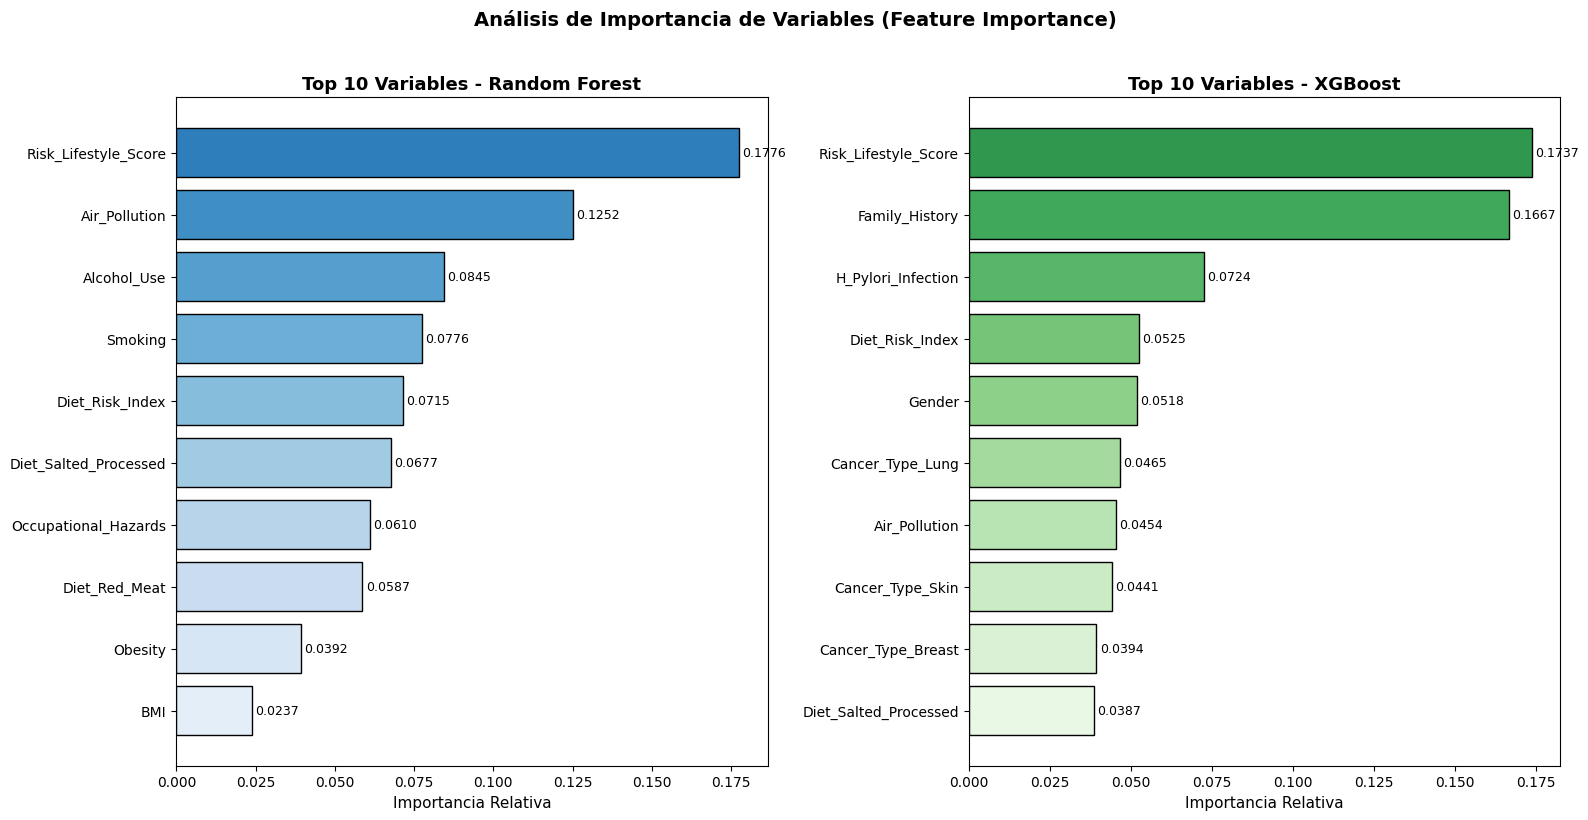

 Gráfico guardado: feature_importance.png

 Variables en el TOP 5 de AMBOS modelos: 2
   ✓ Risk_Lifestyle_Score
   ✓ Diet_Risk_Index


In [160]:
print(" 4. INTERPRETABILIDAD - FEATURE IMPORTANCE")

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': xgb.feature_importances_
}).sort_values('Importancia', ascending=False)

# Top 5 variables más importantes
print("\n TOP 5 VARIABLES - RANDOM FOREST:")
print(rf_importance.head(5).to_string(index=False))

print("\n TOP 5 VARIABLES - XGBOOST:")
print(xgb_importance.head(5).to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest - Top 10
top10_rf = rf_importance.head(10)
colors_rf = plt.cm.Blues_r(np.linspace(0.3, 0.9, 10))
bars_rf = axes[0].barh(range(10), top10_rf['Importancia'].values, color=colors_rf, edgecolor='black')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top10_rf['Variable'].values)
axes[0].set_xlabel('Importancia Relativa', fontsize=11)
axes[0].set_title('Top 10 Variables - Random Forest', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Añadir valores de cada barra
for i, (bar, val) in enumerate(zip(bars_rf, top10_rf['Importancia'].values)):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{val:.4f}', va='center', fontsize=9)

# XGBoost - Top 10
top10_xgb = xgb_importance.head(10)
colors_xgb = plt.cm.Greens_r(np.linspace(0.3, 0.9, 10))
bars_xgb = axes[1].barh(range(10), top10_xgb['Importancia'].values, color=colors_xgb, edgecolor='black')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top10_xgb['Variable'].values)
axes[1].set_xlabel('Importancia Relativa', fontsize=11)
axes[1].set_title('Top 10 Variables - XGBoost', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

for i, (bar, val) in enumerate(zip(bars_xgb, top10_xgb['Importancia'].values)):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2, 
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Análisis de Importancia de Variables (Feature Importance)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico guardado: feature_importance.png")

# Variables comunes en el Top 5 de ambos modelos
rf_top5_set = set(rf_importance.head(5)['Variable'].tolist())
xgb_top5_set = set(xgb_importance.head(5)['Variable'].tolist())
comunes = rf_top5_set.intersection(xgb_top5_set)

print(f"\n Variables en el TOP 5 de AMBOS modelos: {len(comunes)}")
if comunes:
    for var in comunes:
        print(f"   ✓ {var}")
else:
    print("   No hay variables comunes en el Top 5 de ambos modelos.")